In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

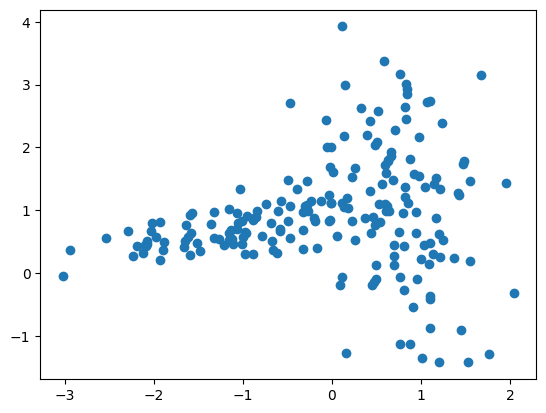

In [3]:
from sklearn.datasets import make_classification

Xc_2,_= make_classification(n_samples=200,
                            n_features=2,
                            n_informative=2,
                            n_redundant=0,
                            random_state=0,
                            n_clusters_per_class=1,
                            class_sep = 0.8)
plt.figure()
plt.scatter  (Xc_2[:,0], Xc_2[:,1])

In [4]:
points = Xc_2

Text(0.5, 1.0, 'Initial centroids')

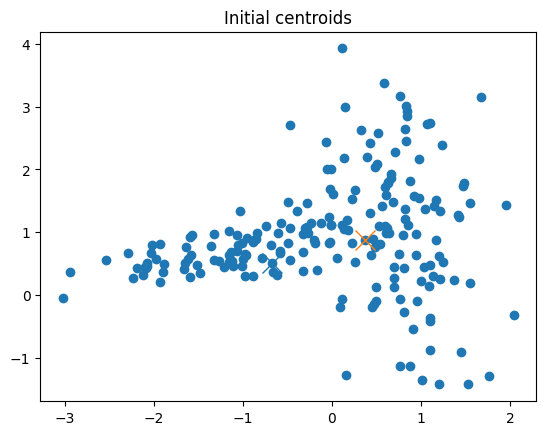

In [5]:
def init_centroids(k, points):
    indices = np.random.choice(len(points), k, replace=False)
    return points[indices]

k = 2
centroids = init_centroids(k, points)

plt.figure()
plt.scatter(points[:,0], points[:,1])
for c in centroids:
    plt.plot(c[0], c[1], 'x', markersize=14)
plt.title("Initial centroids")

Text(0.5, 1.0, 'After assignment')

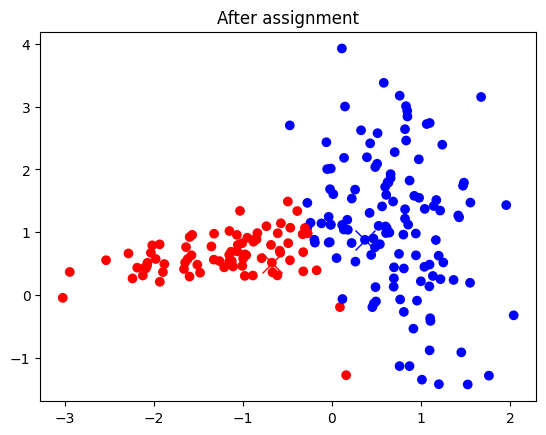

In [6]:
def compute_distances(samples, centroids):
    return np.array([
        np.linalg.norm(samples - c, axis=1)
        for c in centroids
    ])

def compute_closest(points, centroids):
    distances = compute_distances(points, centroids)
    return np.argmin(distances, axis=0)

closest = compute_closest(points, centroids)

colors = np.array(['red','blue','green','orange'])

plt.figure()
plt.scatter(points[:,0], points[:,1], c=colors[closest])
for i, c in enumerate(centroids):
    plt.plot(c[0], c[1], 'x', color=colors[i], markersize=14)
plt.title("After assignment")

Text(0.5, 1.0, 'Updated centroids')

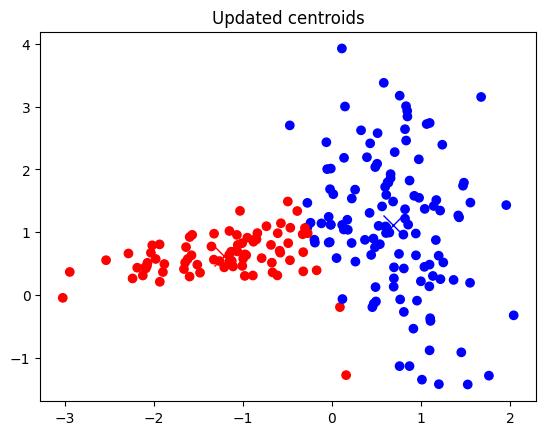

In [7]:
def compute_means(points, centroids, closest):
    new_centroids = []
    for i in range(len(centroids)):
        if i not in closest:
            new_centroids.append(centroids[i])
        else:
            new_centroids.append(points[closest == i].mean(axis=0))
    return np.array(new_centroids)

centroids = compute_means(points, centroids, closest)

plt.figure()
plt.scatter(points[:,0], points[:,1], c=colors[closest])
for i, c in enumerate(centroids):
    plt.plot(c[0], c[1], 'x', color=colors[i], markersize=14)
plt.title("Updated centroids")

In [8]:
def J(points, centroids, closest):
    total = 0
    for i in range(len(centroids)):
        cluster_points = points[closest == i]
        if len(cluster_points) > 0:
            total += np.sum(np.linalg.norm(cluster_points - centroids[i], axis=1))
    return total / len(points)

cost = J(points, centroids, closest)
print("Cost J =", cost)

Cost J = 0.8836058211821826


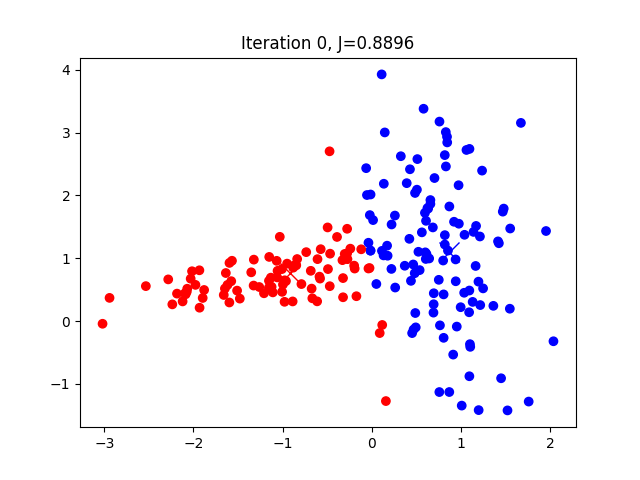

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import Image, display

mpl.rcParams['animation.embed_limit'] = 50.0
fig, ax = plt.subplots()
centroids = init_centroids(2, points)
J_hist = []

def update(frame):
    ax.clear()
    global centroids, J_hist

    closest = compute_closest(points, centroids)
    ax.scatter(points[:,0], points[:,1], c=colors[closest])
    for i, c in enumerate(centroids):
        ax.plot(c[0], c[1], 'x', color=colors[i], markersize=14)

    centroids = compute_means(points, centroids, closest)
    cost = J(points, centroids, closest)
    J_hist.append(cost)
    ax.set_title(f"Iteration {frame}, J={cost:.4f}")
    if len(J_hist) > 1:
        if abs(J_hist[-1] - J_hist[-2]) < 1e-6:
            anim.event_source.stop()

anim = animation.FuncAnimation(
    fig,
    update,
    frames=20,
    interval=1000,
    repeat=True,
    cache_frame_data=False
)

anim.save('kmeans.gif', writer='pillow', fps=1)
plt.close()
display(Image(filename='kmeans.gif'))

Text(0.5, 1.0, 'Convergence of K-means')

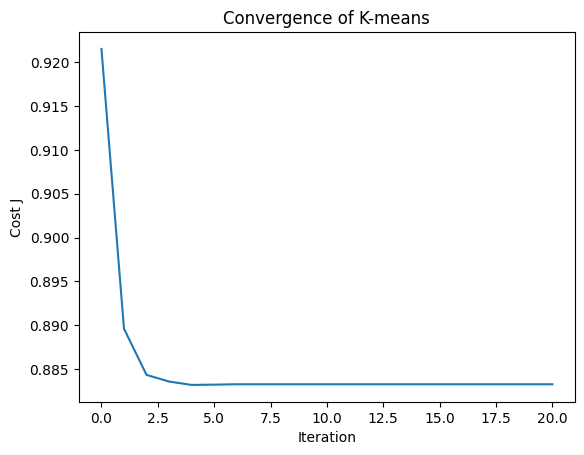

In [10]:
plt.figure()
plt.plot(J_hist)
plt.xlabel("Iteration")
plt.ylabel("Cost J")
plt.title("Convergence of K-means")

Text(0.5, 1.0, 'Best result, J=0.8833')

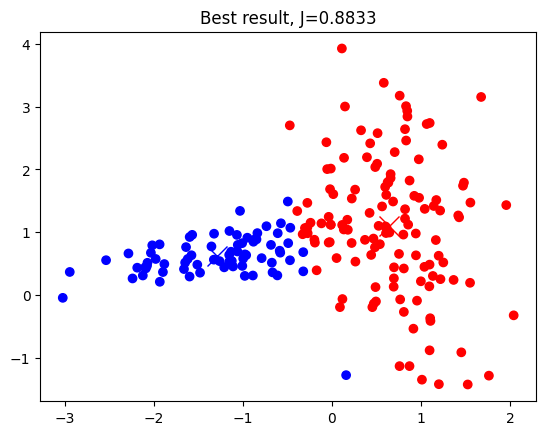

In [11]:
best = None

for _ in range(100):
    centroids = init_centroids(2, points)
    
    for _ in range(20):
        closest = compute_closest(points, centroids)
        centroids = compute_means(points, centroids, closest)
    
    cost = J(points, centroids, closest)
    
    if best is None or cost < best[2]:
        best = (centroids, closest, cost)

best_centroids, best_labels, best_cost = best

plt.figure()
plt.scatter(points[:,0], points[:,1], c=colors[best_labels])

for i, c in enumerate(best_centroids):
    plt.plot(c[0], c[1], 'x', color=colors[i], markersize=14)

plt.title(f"Best result, J={best_cost:.4f}")